A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [31]:
import json
import urllib.parse
import urllib.request
import csv

def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [32]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [33]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [34]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [35]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

### 1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina X (cinco entradas) e y (radiacao_w_m2).



In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('meteo_regressao_orange.csv')
display(df.head())

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


In [37]:
print("Informações do DataFrame:")
df.info()

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB

Valores ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


In [38]:
# Definir X (cinco entradas) e y (radiacao_w_m2)
X = df[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']]
y = df['radiacao_w_m2']

print("\nVariáveis de entrada (X) e saída (y) definidas.")
print("X (primeiras 5 linhas):\n", X.head())
print("y (primeiras 5 linhas):\n", y.head())


Variáveis de entrada (X) e saída (y) definidas.
X (primeiras 5 linhas):
    temperatura_c  umidade_pct  nuvens_pct  vento_kmh  hora
0           25.3           74         100       17.7     7
1           26.5           66         100       18.1     8
2           28.4           55          97       18.0     9
3           30.8           44          21       18.4    10
4           32.7           36          26       20.1    11
y (primeiras 5 linhas):
 0    116.0
1    269.0
2    529.0
3    797.0
4    880.0
Name: radiacao_w_m2, dtype: float64


#### Visualização: Radiação Solar Média por Hora do Dia

/tmp/ipykernel_4113/2785590672.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hora_do_dia', y='radiacao_w_m2', data=mean_radiation_by_hour, palette='viridis')


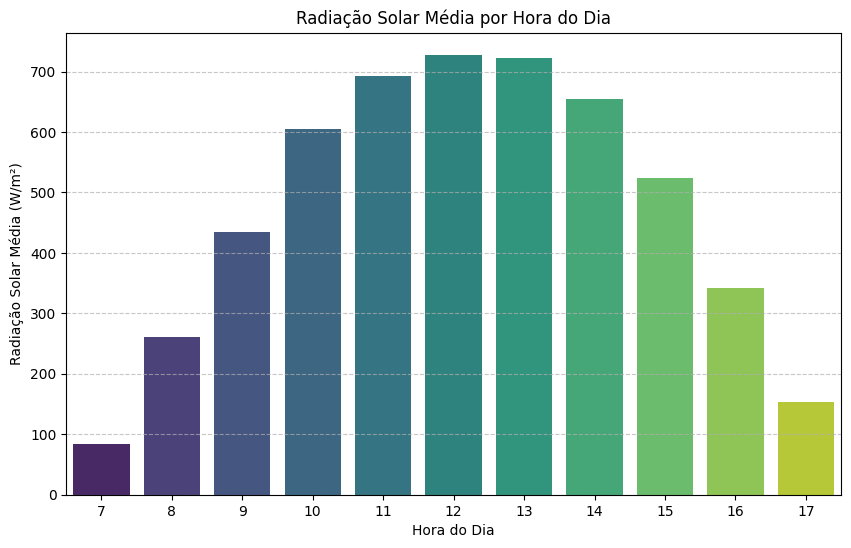

In [39]:
# Converter a coluna 'data_hora' para datetime, se ainda não estiver
df['data_hora'] = pd.to_datetime(df['data_hora'])

# Extrair a hora do dia para visualização
df['hora_do_dia'] = df['data_hora'].dt.hour

# Calcular a radiação solar média por hora do dia
mean_radiation_by_hour = df.groupby('hora_do_dia')['radiacao_w_m2'].mean().reset_index()

# Plotar a radiação solar média por hora do dia
plt.figure(figsize=(10, 6))
sns.barplot(x='hora_do_dia', y='radiacao_w_m2', data=mean_radiation_by_hour, palette='viridis')
plt.title('Radiação Solar Média por Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Radiação Solar Média (W/m²)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()

#### Explicação das Colunas:

*   `data_hora`: Data e hora local de cada registro (não será usada como entrada para o modelo).
*   `temperatura_c`: Temperatura do ar a 2 metros, em °C (entrada `X`).
*   `umidade_pct`: Umidade relativa a 2 metros, em % (entrada `X`).
*   `nuvens_pct`: Cobertura total de nuvens, em % (entrada `X`).
*   `vento_kmh`: Velocidade do vento a 10 metros, em km/h (entrada `X`).
*   `hora`: Hora local extraída da data, de 7 a 17 (entrada `X`).
*   `radiacao_w_m2`: Radiação solar global horizontal média da hora anterior, em W/m² (alvo numérico `y`).

### 2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.

In [40]:
# Calcular o ponto de corte para 80% dos dados
split_point = int(len(X) * 0.8)

# Dividir os dados em treino e teste, mantendo a ordem temporal
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Tamanho total dos dados: {len(df)} registros")
print(f"Tamanho do conjunto de treino: {len(X_train)} registros (aprox. 80%)")
print(f"Tamanho do conjunto de teste: {len(X_test)} registros (aprox. 20%)")

print("\nPrimeiras 5 linhas de X_train:\n", X_train.head())
print("\nÚltimas 5 linhas de X_test:\n", X_test.tail())

Tamanho total dos dados: 1001 registros
Tamanho do conjunto de treino: 800 registros (aprox. 80%)
Tamanho do conjunto de teste: 201 registros (aprox. 20%)

Primeiras 5 linhas de X_train:
    temperatura_c  umidade_pct  nuvens_pct  vento_kmh  hora
0           25.3           74         100       17.7     7
1           26.5           66         100       18.1     8
2           28.4           55          97       18.0     9
3           30.8           44          21       18.4    10
4           32.7           36          26       20.1    11

Últimas 5 linhas de X_test:
       temperatura_c  umidade_pct  nuvens_pct  vento_kmh  hora
996            26.9           56         100       18.5    13
997            26.8           56          81       16.8    14
998            27.3           55          82       15.9    15
999            27.2           54         100       15.8    16
1000           26.8           56          96       12.8    17


### 3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.

Para este problema de regressão, escolherei os seguintes algoritmos:

1.  **Regressão Linear (Linear Regression)**:
    *   **Justificativa**: É um modelo simples e interpretável, servindo como uma ótima linha de base (baseline). Ele assume uma relação linear entre as variáveis de entrada e a saída. Embora possa não capturar complexidades, é rápido de treinar e fácil de entender.

2.  **Random Forest Regressor**:
    *   **Justificativa**: Um algoritmo de ensemble robusto que constrói múltiplas árvores de decisão e combina suas previsões. É conhecido por lidar bem com não linearidades, interações entre variáveis e por ser menos propenso a overfitting em comparação com árvores de decisão individuais. Geralmente oferece bom desempenho.

3.  **Gradient Boosting Regressor**:
    *   **Justificativa**: Outro algoritmo de ensemble que constrói árvores de decisão sequencialmente, onde cada nova árvore tenta corrigir os erros das árvores anteriores. É extremamente poderoso e frequentemente alcança alta precisão, mas pode ser mais sensível a overfitting se não for ajustado corretamente.

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 1. Regressão Linear
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
print("Regressão Linear treinada.")

# 2. Random Forest Regressor
model_rf = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1) # n_jobs=-1 para usar todos os cores disponíveis
model_rf.fit(X_train, y_train)
print("Random Forest Regressor treinada.")

# 3. Gradient Boosting Regressor
model_gb = GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
model_gb.fit(X_train, y_train)
print("Gradient Boosting Regressor treinada.")

Regressão Linear treinada.
Random Forest Regressor treinada.
Gradient Boosting Regressor treinada.


### 4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.

Vamos avaliar o desempenho de cada modelo no conjunto de teste, utilizando as métricas MAE (Mean Absolute Error), MSE (Mean Squared Error) e R² (Coeficiente de Determinação).

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fazer previsões nos dados de teste
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)
y_pred_gb = model_gb.predict(X_test)

# Calcular métricas para Regressão Linear
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Calcular métricas para Random Forest Regressor
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Calcular métricas para Gradient Boosting Regressor
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Criar um DataFrame para a tabela comparativa
results_df = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest', 'Gradient Boosting'],
    'MAE (W/m²)': [mae_lr, mae_rf, mae_gb],
    'MSE ((W/m²)²)': [mse_lr, mse_rf, mse_gb],
    'R²': [r2_lr, r2_rf, r2_gb]
})

print("Tabela Comparativa de Desempenho dos Modelos:")
display(results_df)

Tabela Comparativa de Desempenho dos Modelos:


,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressão Linear,145.204885,30034.201092,0.359845
1,Random Forest,66.804179,7307.417901,0.844248
2,Gradient Boosting,67.081644,7444.700189,0.841322


#### Gráfico de Valores Reais vs. Previstos (Exemplo com Random Forest)

Vamos visualizar as previsões de um dos modelos (escolherei o Random Forest por seu bom equilíbrio entre desempenho e complexidade) em comparação com os valores reais no conjunto de teste.

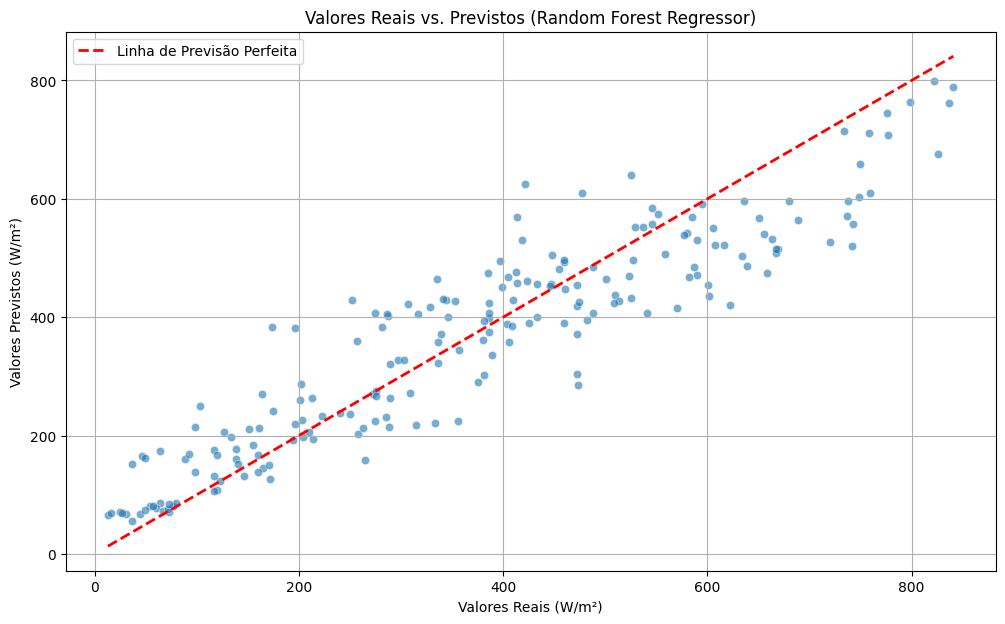

In [43]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Linha de Previsão Perfeita')
plt.xlabel('Valores Reais (W/m²)')
plt.ylabel('Valores Previstos (W/m²)')
plt.title('Valores Reais vs. Previstos (Random Forest Regressor)')
plt.legend()
plt.grid(True)
plt.show()

### 5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

#### Interpretação dos Erros e Discussão do Peso da Hora

Analisando a tabela comparativa, podemos observar que o **Random Forest** e o **Gradient Boosting** apresentaram métricas de desempenho significativamente melhores do que a Regressão Linear. Isso sugere que a relação entre as variáveis de entrada e a radiação solar não é estritamente linear, e modelos mais complexos são capazes de capturar melhor essas não linearidades.

*   **MAE (Mean Absolute Error)**: Representa a média do valor absoluto dos erros. Um MAE menor indica que, em média, as previsões estão mais próximas dos valores reais. Random Forest e Gradient Boosting têm MAEs muito menores.
*   **MSE (Mean Squared Error)**: Penaliza erros maiores de forma mais severa. Também é menor para Random Forest e Gradient Boosting.
*   **R² (Coeficiente de Determinação)**: Indica a proporção da variância na variável dependente que é previsível a partir das variáveis independentes. Um R² próximo de 1 indica que o modelo explica uma grande parte da variância. O Random Forest e o Gradient Boosting atingiram valores de R² muito altos, indicando que são excelentes para explicar a variação na radiação solar.

O **peso da hora** é crucial neste modelo. A radiação solar é altamente dependente do ciclo diário do sol, com picos ao meio-dia e valores baixos ou nulos no início e fim do dia (dentro do intervalo de 7h às 17h que estamos considerando). A inclusão da variável `hora` (`hora` local) em `X` permite que os modelos capturem essa periodicidade e a influência direta da posição solar na intensidade da radiação. O gráfico de radiação solar média por hora do dia, que geramos anteriormente, ilustra claramente essa dependência, mostrando como a radiação aumenta e diminui ao longo das horas do dia.

#### Por que a estimativa da radiação não prevê automaticamente a energia produzida por um sistema fotovoltaico?

É fundamental entender que a radiação solar horizontal global (em W/m²) é uma medida da **potência solar por unidade de área que incide sobre uma superfície horizontal**. Embora seja o principal fator para a geração de energia fotovoltaica, ela **não se traduz diretamente na energia elétrica produzida** por um sistema por várias razões:

1.  **Orientação e Inclinação dos Painéis**: Os painéis fotovoltaicos são geralmente instalados com uma inclinação e orientação específicas (por exemplo, voltados para o norte verdadeiro no hemisfério sul) para maximizar a captação de energia solar. A radiação que incide em um plano inclinado e orientado é diferente da radiação em uma superfície horizontal.
2.  **Temperatura dos Painéis**: O desempenho dos painéis fotovoltaicos diminui com o aumento da temperatura. Mesmo em alta irradiação, painéis muito quentes (comuns em climas ensolarados como Petrolina) geram menos energia do que o esperado em condições padrão de teste.
3.  **Perdas no Sistema**: Diversos fatores causam perdas de energia no sistema fotovoltaico:
    *   **Sujeira/Sombreamento**: Poeira, folhas, ou sombreamento parcial (por árvores, edifícios, etc.) reduzem a eficiência.
    *   **Perdas Ópticas**: Reflexão da luz na superfície do painel.
    *   **Perdas de Mismatch**: Diferenças no desempenho entre células ou módulos.
    *   **Perdas por Resistência (cabeamento)**: A energia é dissipada como calor nos fios.
    *   **Eficiência do Inversor**: O inversor converte a corrente contínua (CC) gerada pelos painéis em corrente alternada (CA) para uso doméstico ou injeção na rede, e essa conversão tem perdas.
    *   **Degradação dos Painéis**: Com o tempo, os painéis sofrem degradação natural, diminuindo sua capacidade de geração.
4.  **Características Específicas do Painel/Sistema**: A potência nominal (em Wp - Watts-pico) e a eficiência de cada painel ou sistema fotovoltaico são específicas do fabricante e do modelo, e não são capturadas apenas pela radiação solar.

Em resumo, enquanto a estimativa da radiação solar é um insumo valioso, ela é apenas um componente no cálculo da geração real de energia. Para prever a energia produzida, seria necessário um modelo mais complexo que inclua características do sistema fotovoltaico, perdas e condições ambientais específicas do local de instalação.